# Module 1 — Basic Physical and Chemical Structure of the Troposphere and Stratosphere
### B4 Chemistry in the Atmosphere · companion notebook

Covers Exercise 1 (number density), the hydrostatic/scale-height relation, and Exercise 2
(column amount), from `lectures/01-basic-structure-troposphere-stratosphere.md`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['font.size'] = 11

kB = 1.38e-23   # J/K
R = 8.314       # J/mol/K
NA = 6.022e23   # /mol
g = 9.81        # m/s^2

## Exercise 1 — number density at different altitudes

$$\frac{\#}{V} = \frac{p}{k_B T}$$

In [2]:
def number_density(p_pa, T_K):
    """Number density in molecules/cm^3, given pressure in Pa and temperature in K."""
    n_per_m3 = p_pa / (kB * T_K)
    return n_per_m3 / 1e6   # convert m^-3 -> cm^-3

# Check against the notes: 298 K, 1 bar (100,000 Pa)
n0 = number_density(1e5, 298)
print(f"[M] at 298 K, 1 bar = {n0:.3e} molecules/cm^3")
print("(notes value: 2.43e19 molecules/cm^3)")

[M] at 298 K, 1 bar = 2.432e+19 molecules/cm^3
(notes value: 2.43e19 molecules/cm^3)


## Scale height and the barometric law

$$H = \frac{RT}{Mg}, \qquad p = p_0 e^{-z/H}, \qquad [M] = [M]_0 e^{-z/H}$$

In [3]:
M_air = 28.9e-3   # kg/mol
T_avg = 250        # K, a representative average atmospheric temperature

H = R * T_avg / (M_air * g)
print(f"Scale height H = {H/1000:.2f} km (notes: 6-7.5 km)")

Scale height H = 7.33 km (notes: 6-7.5 km)


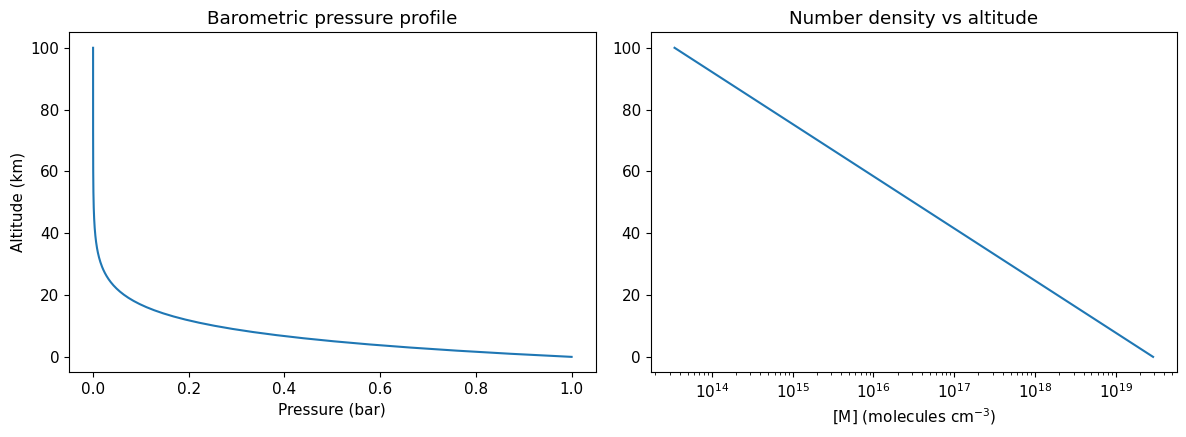

Ratio [M](16km)/[M](0km) = 0.112 (expect ~0.1)


In [4]:
z_km = np.linspace(0, 100, 200)
z_m = z_km * 1000

p0 = 1e5           # Pa, surface pressure
p = p0 * np.exp(-z_m / H)
M_conc = number_density(p, T_avg)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(p/1e5, z_km)
axes[0].set_xlabel('Pressure (bar)')
axes[0].set_ylabel('Altitude (km)')
axes[0].set_title('Barometric pressure profile')

axes[1].semilogx(M_conc, z_km)
axes[1].set_xlabel('[M] (molecules cm$^{-3}$)')
axes[1].set_title('Number density vs altitude')
plt.tight_layout()
plt.show()

# Sanity check: factor of ~10 drop per ~16 km, as the notes state
ratio = M_conc[np.argmin(np.abs(z_km-16))] / M_conc[0]
print(f"Ratio [M](16km)/[M](0km) = {ratio:.3f} (expect ~0.1)")

## Exercise 2 — column amount of a well-mixed gas

$$\text{Column} = [x]_0 \cdot H$$

We reproduce the ozone column example: a well-mixed gas at some surface mixing ratio, using the
scale height, should come out close to the ~300 DU quoted in the notes for ozone (ozone isn't
actually well-mixed — it peaks in the stratosphere — but this illustrates the mechanics of the
column integral for the well-mixed case in Exercise 2, e.g. for a long-lived tracer).

In [5]:
DU = 2.69e16   # molecules/cm^2 per Dobson Unit

def column_well_mixed(mixing_ratio, surface_T=288, surface_p=1e5, H_km=None):
    M0 = number_density(surface_p, surface_T)   # molecules/cm^3 at the surface
    x0 = mixing_ratio * M0
    H_use = (H_km * 1000) if H_km else H
    column_cm2 = x0 * (H_use * 100)   # H in cm
    return column_cm2

# Example: a hypothetical well-mixed gas at 80 ppb (O3-like surface mixing ratio)
col = column_well_mixed(80e-9)
print(f"Column = {col:.3e} molecules/cm^2 = {col/DU:.1f} DU")
print("(Real ozone columns are ~300 DU, but O3 is NOT well-mixed -- see discussion below.)")

Column = 1.476e+18 molecules/cm^2 = 54.9 DU
(Real ozone columns are ~300 DU, but O3 is NOT well-mixed -- see discussion below.)


**Why doesn't the well-mixed approximation reproduce the real ~300 DU ozone column exactly?**
Ozone peaks in the mid-stratosphere rather than being uniformly mixed with altitude — see Fig 1.6.
The `column_well_mixed` function above is only valid for gases whose *mixing ratio* (not
concentration) is constant with height. Exercise 3 below asks you to do the column integral
properly for a peaked profile like ozone's.

## Exercises

1. **Temperature dependence.** Recompute [M] at the surface for T = 250 K, 273 K, 298 K, 310 K.
   How much does number density change over this range, for fixed pressure? Which matters more
   for [M] — typical variations in T, or the exponential fall-off with altitude?

2. **Your own altitude.** Using the scale height calculated above, estimate the pressure and [M]
   at the summit of Mount Everest (~8850 m) and at a typical cruising altitude for a commercial
   jet (~11 km). Compare to published values.

3. **A peaked profile.** Ozone's number density roughly follows a Gaussian in altitude, peaking
   near 25 km. Write a function `n_O3(z)` for such a profile (choose a peak concentration and
   width so the column works out close to 300 DU), integrate it numerically (`np.trapz` or
   `scipy.integrate.quad`), and convert to Dobson Units. Compare your peaked-profile column to
   the naive well-mixed estimate from Exercise 2 above.

4. **Mixing timescales.** Using Figure 1.4 as a guide, if a pollutant plume mixes vertically
   through the troposphere in ~days but takes ~months to a year to mix between hemispheres, what
   does that imply about how quickly a short-lived vs. long-lived species becomes globally
   well-mixed? (No calculation needed — a 2–3 sentence answer.)